2.1 理论计算题

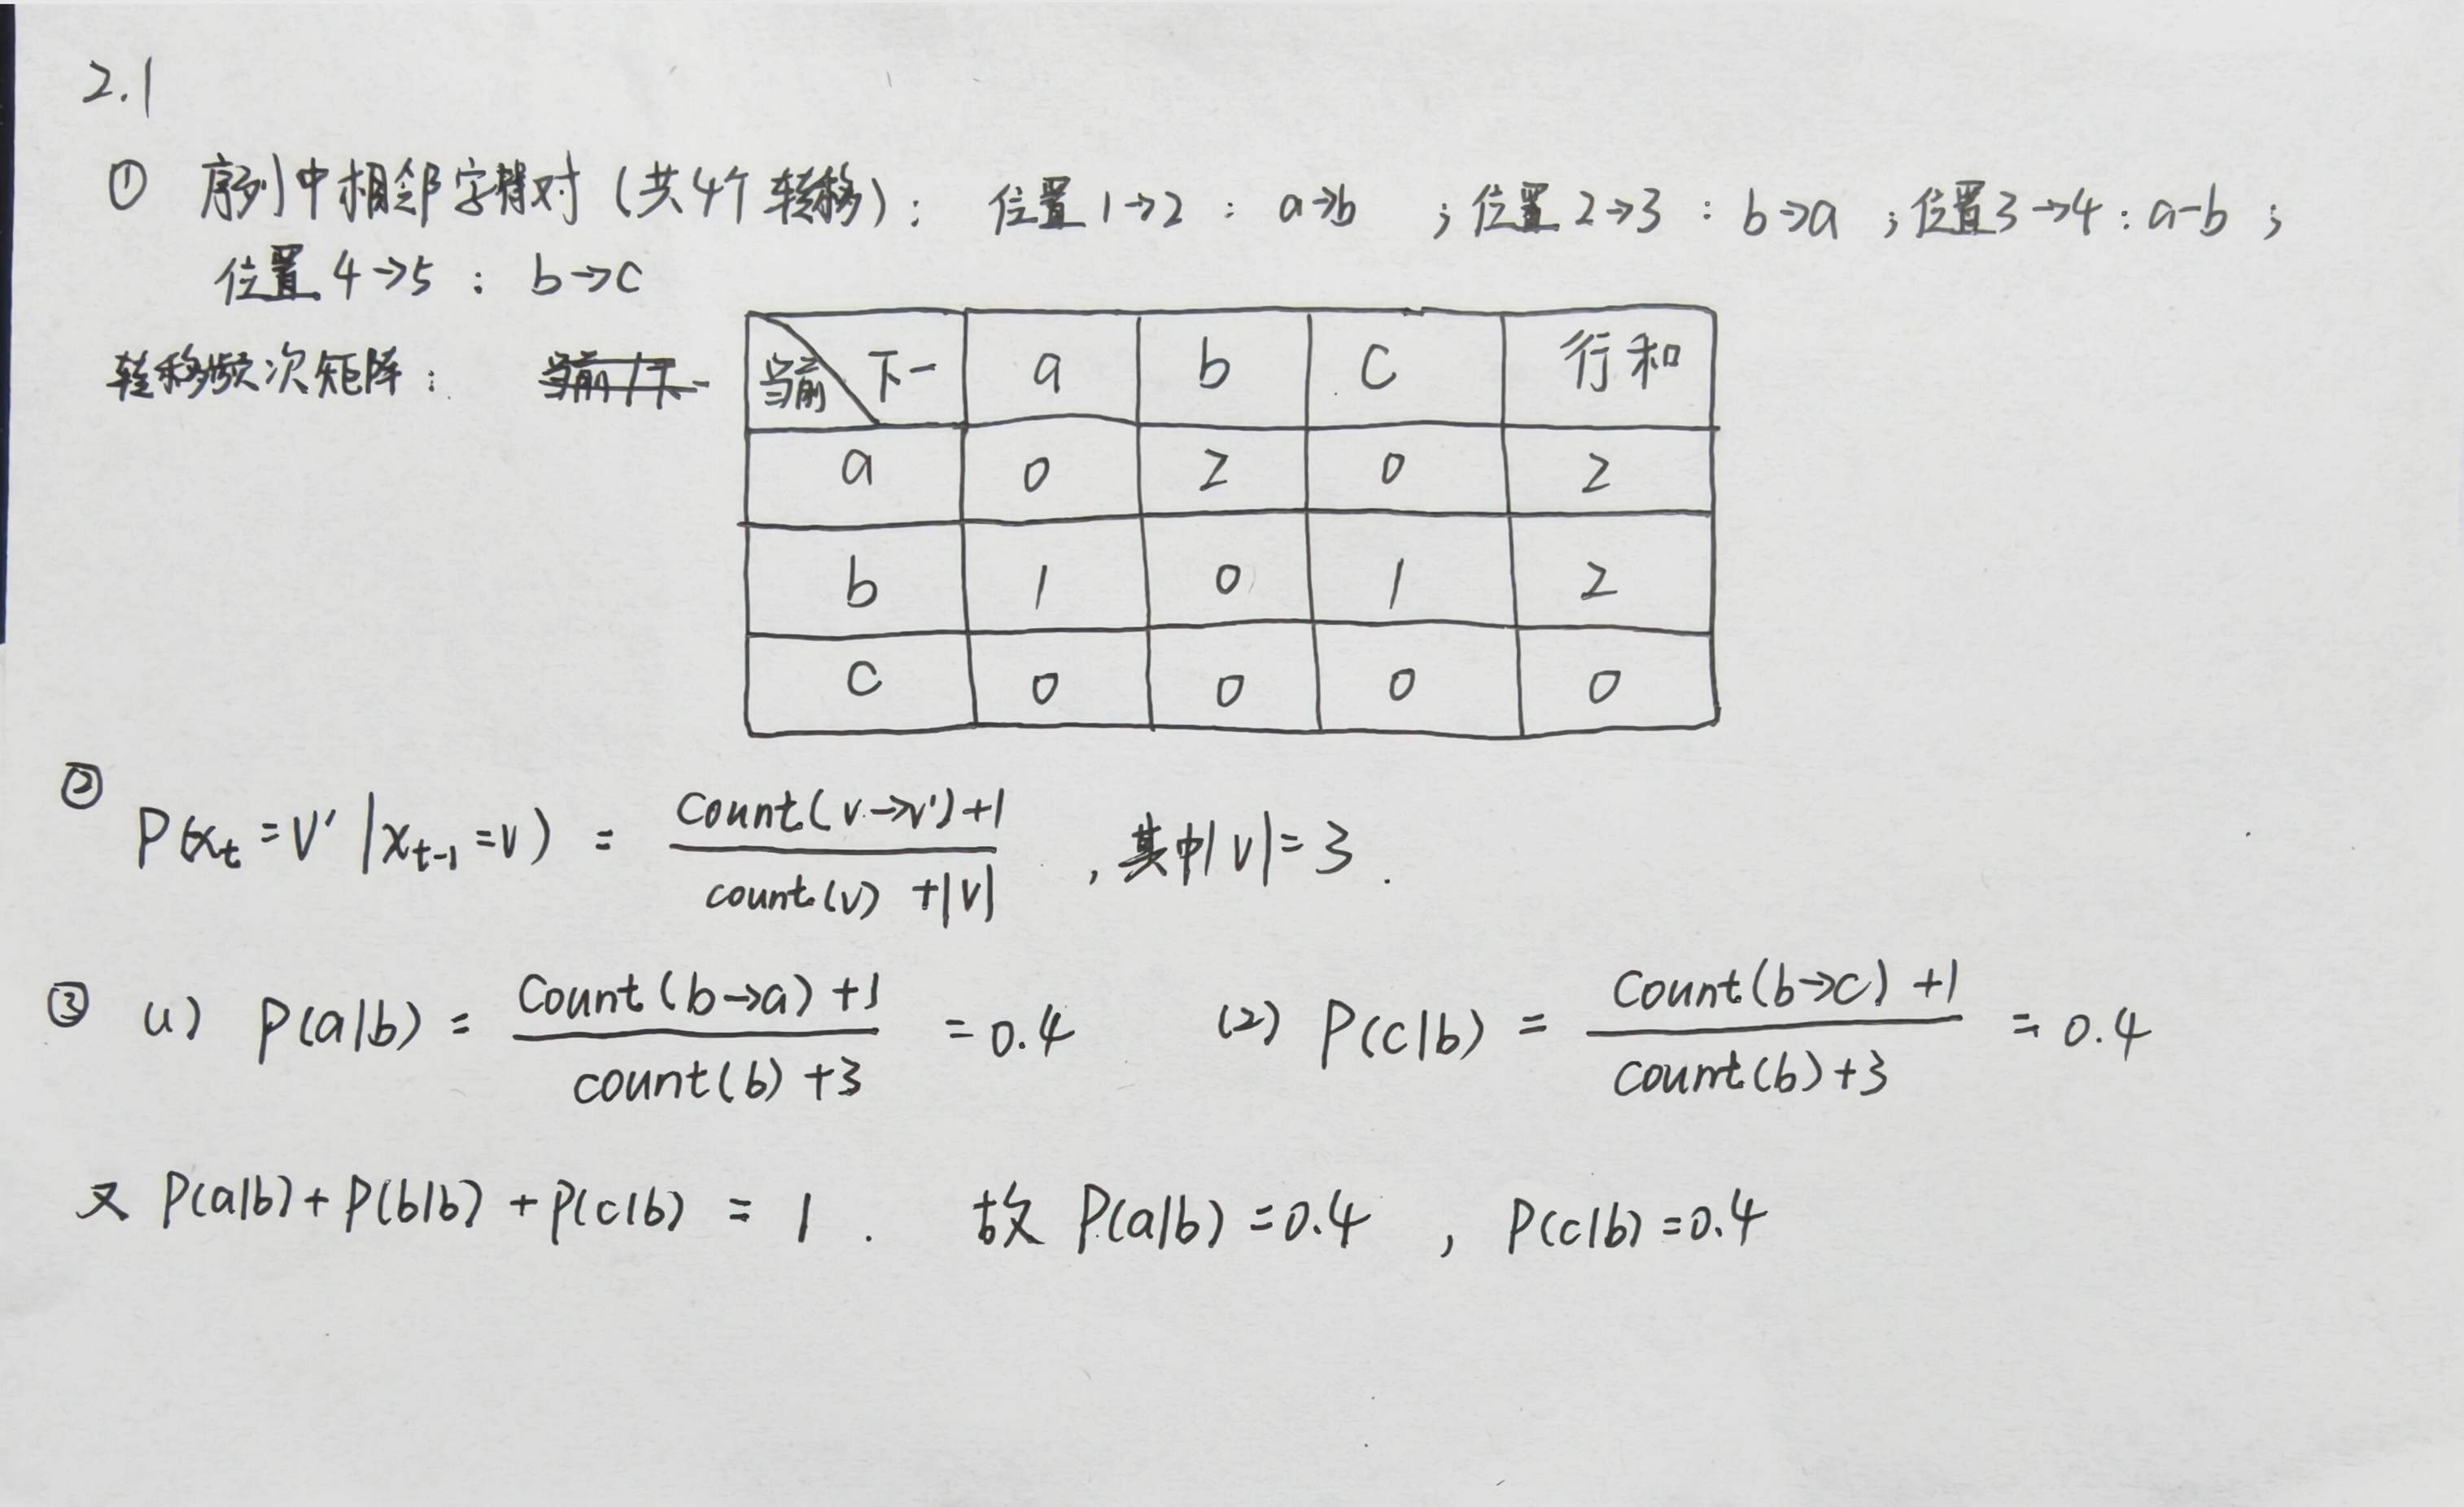

In [2]:
#2.2编程题
import re
from collections import Counter

def preprocess_text(text, n):
    # 1. 转小写，去标点（保留字母和空格）
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 2. 按空格分词，去除空串
    tokens = text.split()
    tokens = [t for t in tokens if t]
    
    # 3. 构建词汇表：按频率排序，从0开始编号
    freq = Counter(tokens)
    vocab = {word: idx for idx, (word, _) in enumerate(freq.most_common())}
    
    # 4. 生成特征序列和标签
    features = []
    labels = []
    for i in range(len(tokens) - n):
        features.append(tokens[i:i+n])
        labels.append(tokens[i+n])
    
    return vocab, (features, labels)

# ========== 测试输出 ==========
print("="*50)
print("2.2 序列模型 - 预处理函数测试")
print("="*50)

test_texts = [
    ("The time machine", 2),
    ("Hello world! This is a test.", 3),
    ("Python programming, machine learning, deep learning", 2)
]

for text, n in test_texts:
    print(f"\n输入文本: '{text}'")
    print(f"窗口大小 n = {n}")
    vocab, (features, labels) = preprocess_text(text, n)
    print(f"词汇表: {vocab}")
    print(f"特征序列: {features}")
    print(f"标签序列: {labels}")

2.2 序列模型 - 预处理函数测试

输入文本: 'The time machine'
窗口大小 n = 2
词汇表: {'the': 0, 'time': 1, 'machine': 2}
特征序列: [['the', 'time']]
标签序列: ['machine']

输入文本: 'Hello world! This is a test.'
窗口大小 n = 3
词汇表: {'hello': 0, 'world': 1, 'this': 2, 'is': 3, 'a': 4, 'test': 5}
特征序列: [['hello', 'world', 'this'], ['world', 'this', 'is'], ['this', 'is', 'a']]
标签序列: ['is', 'a', 'test']

输入文本: 'Python programming, machine learning, deep learning'
窗口大小 n = 2
词汇表: {'learning': 0, 'python': 1, 'programming': 2, 'machine': 3, 'deep': 4}
特征序列: [['python', 'programming'], ['programming', 'machine'], ['machine', 'learning'], ['learning', 'deep']]
标签序列: ['machine', 'learning', 'deep', 'learning']


3.1 理论计算题

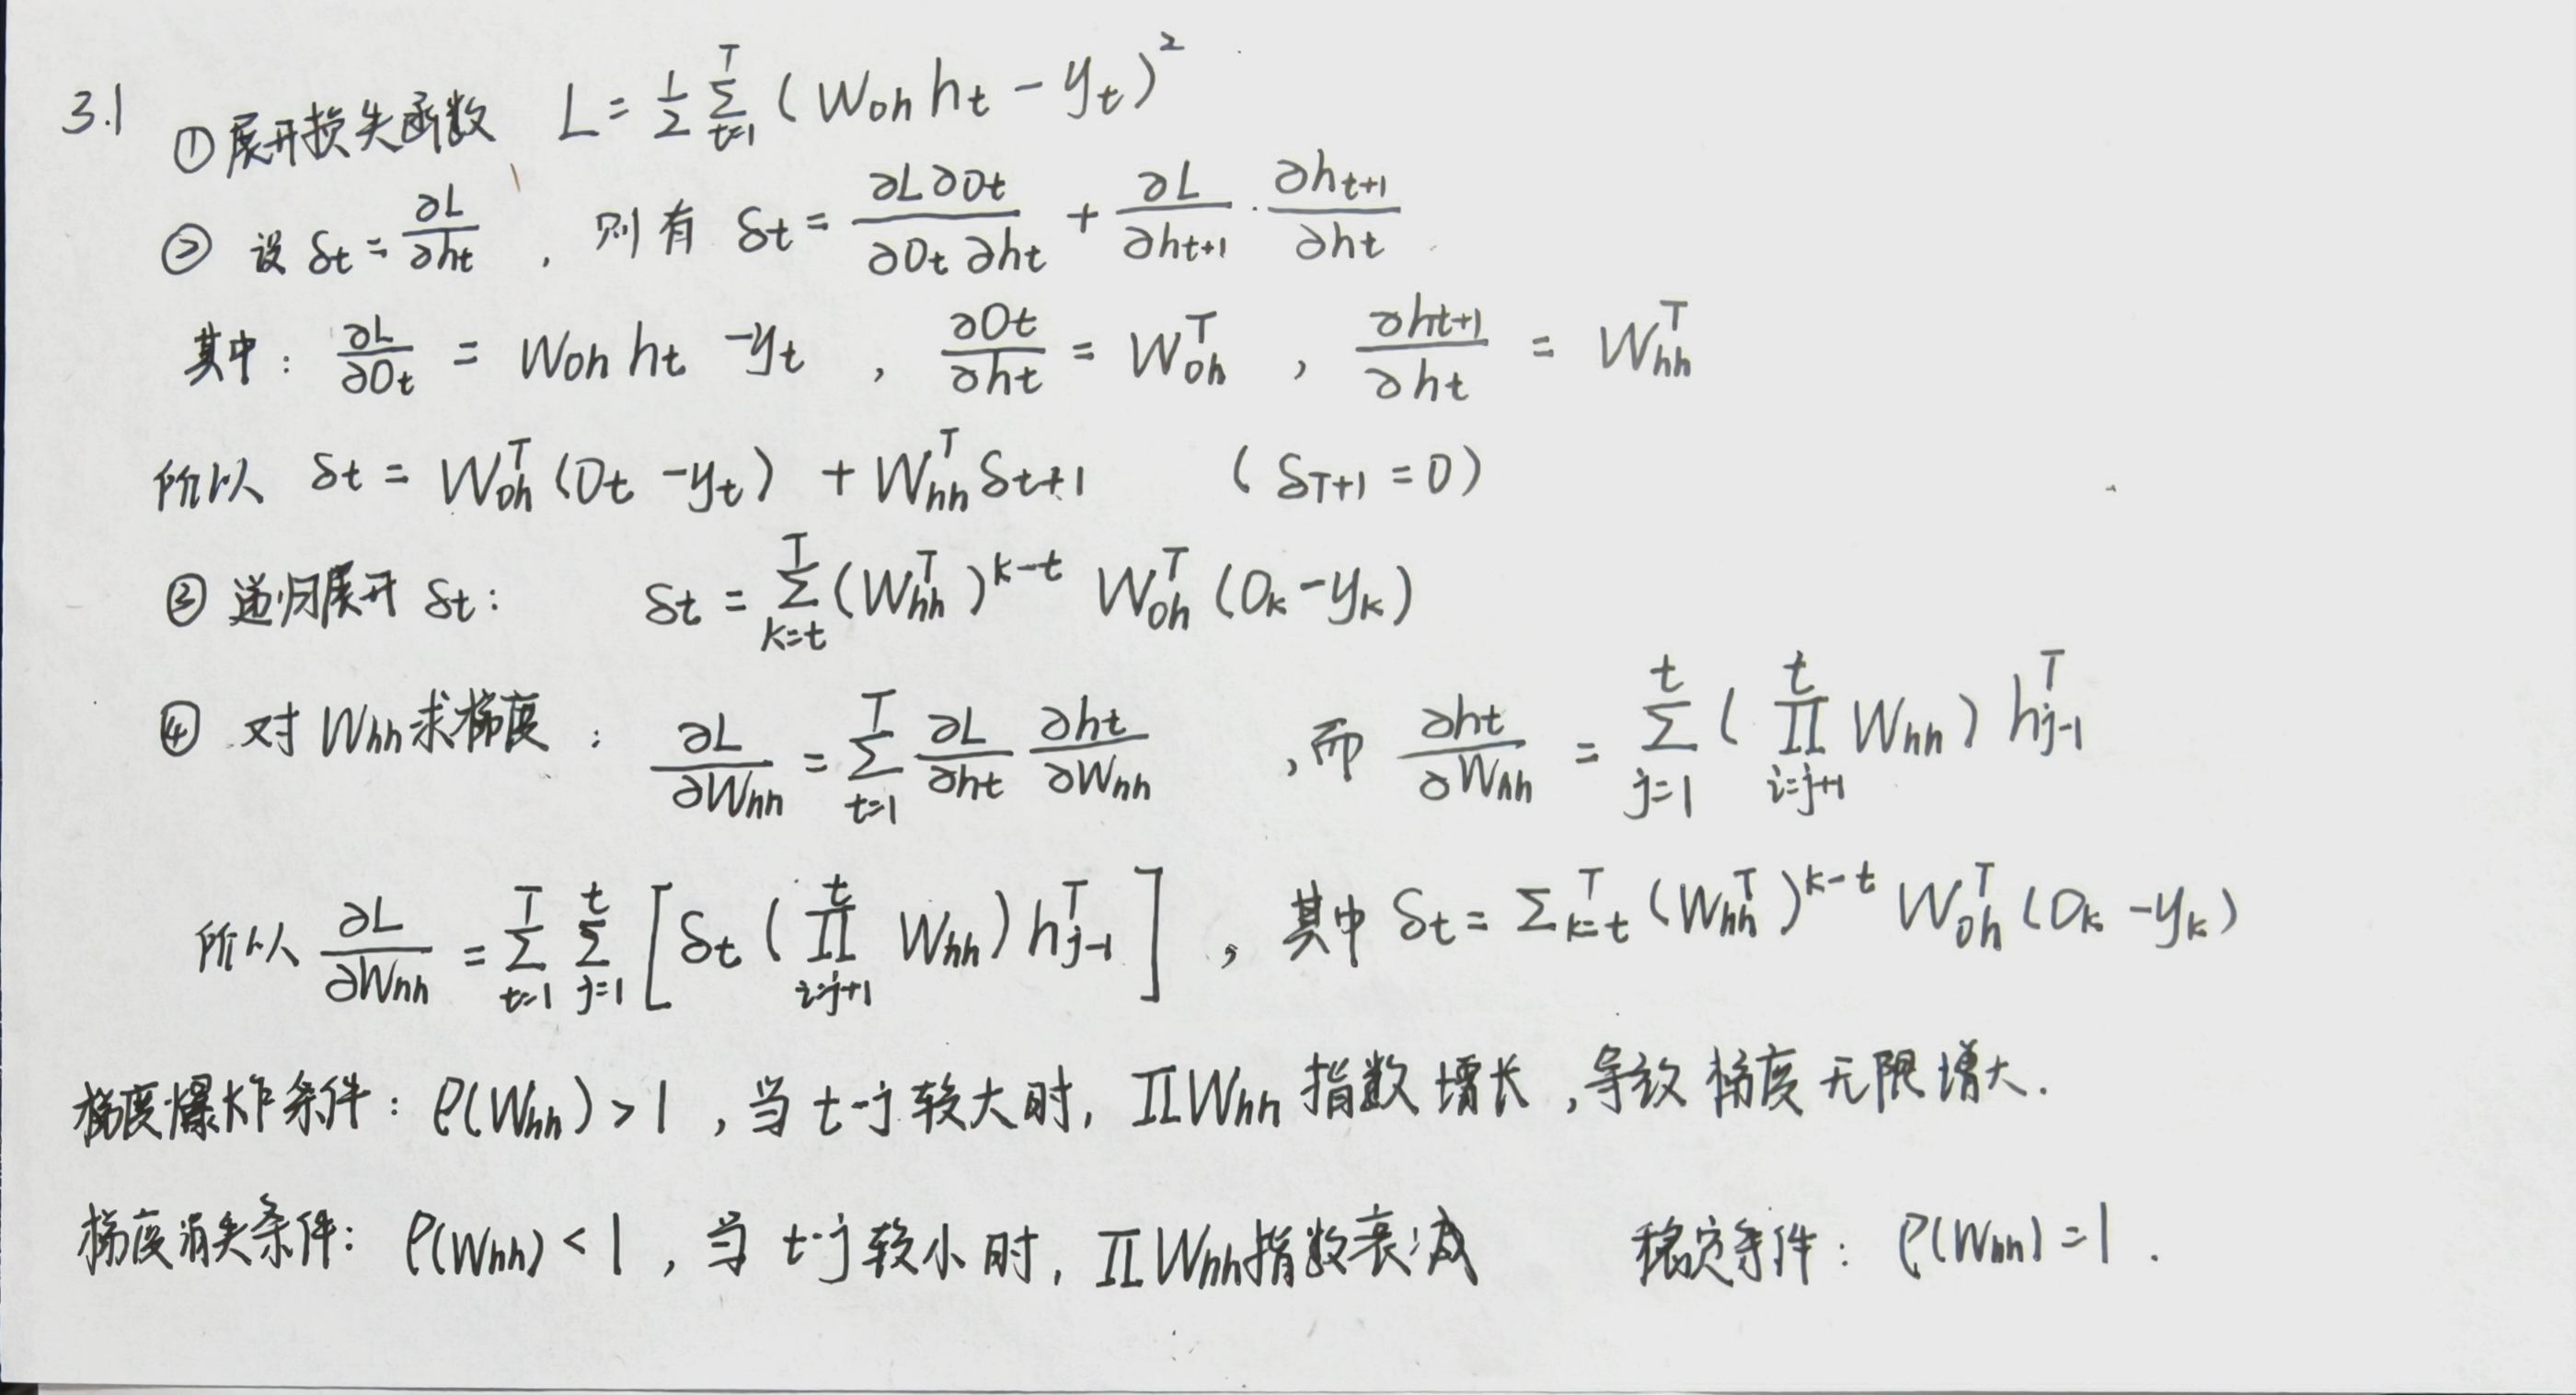

In [3]:
#3.2编程题
import numpy as np

def rnn_cell_forward(x_t, h_prev, W_hh, W_hx, b_h):
    """
    x_t: (batch_size, input_size)
    h_prev: (batch_size, hidden_size)
    W_hh: (hidden_size, hidden_size)
    W_hx: (hidden_size, input_size)
    b_h: (hidden_size,)
    """
    h_t = np.tanh(np.dot(h_prev, W_hh.T) + np.dot(x_t, W_hx.T) + b_h)
    return h_t

def rnn_cell_backward(dh_next, x_t, h_prev, h_t, W_hh, W_hx, b_h):
    """
    dh_next: (batch_size, hidden_size) 上游梯度 dL/dh_t
    返回: dx_t, dh_prev, dW_hh, dW_hx, db_h
    """
    dtanh = dh_next * (1 - h_t ** 2)
    
    dx_t = np.dot(dtanh, W_hx)
    dh_prev = np.dot(dtanh, W_hh)
    
    dW_hx = np.dot(dtanh.T, x_t)
    dW_hh = np.dot(dtanh.T, h_prev)
    db_h = np.sum(dtanh, axis=0)
    
    return dx_t, dh_prev, dW_hh, dW_hx, db_h

# ========== 测试输出 ==========
print("="*50)
print("3.2 RNN单元 - 前向和反向传播测试")
print("="*50)

batch_size, input_size, hidden_size = 2, 3, 4
np.random.seed(42)  # 固定随机种子便于复现

# 初始化输入
x_t = np.random.randn(batch_size, input_size)
h_prev = np.random.randn(batch_size, hidden_size)
W_hh = np.random.randn(hidden_size, hidden_size)
W_hx = np.random.randn(hidden_size, input_size)
b_h = np.random.randn(hidden_size)

print("\n输入参数形状:")
print(f"  x_t: {x_t.shape} (batch_size={batch_size}, input_size={input_size})")
print(f"  h_prev: {h_prev.shape} (batch_size={batch_size}, hidden_size={hidden_size})")
print(f"  W_hh: {W_hh.shape} (hidden_size, hidden_size)")
print(f"  W_hx: {W_hx.shape} (hidden_size, input_size)")
print(f"  b_h: {b_h.shape} (hidden_size,)")

# 前向传播
h_t = rnn_cell_forward(x_t, h_prev, W_hh, W_hx, b_h)
print(f"\n前向传播结果:")
print(f"  h_t 形状: {h_t.shape}")
print(f"  h_t 数值 (前5个): {h_t.flatten()[:5]}")

# 反向传播
dh_next = np.random.randn(batch_size, hidden_size)
dx, dh_prev, dW_hh, dW_hx, db = rnn_cell_backward(dh_next, x_t, h_prev, h_t, W_hh, W_hx, b_h)

print(f"\n反向传播梯度形状:")
print(f"  dx_t: {dx.shape} -> 对输入的梯度")
print(f"  dh_prev: {dh_prev.shape} -> 对上一隐藏状态的梯度")
print(f"  dW_hh: {dW_hh.shape} -> 对隐藏-隐藏权重的梯度")
print(f"  dW_hx: {dW_hx.shape} -> 对输入-隐藏权重的梯度")
print(f"  db_h: {db.shape} -> 对偏置的梯度")

print(f"\n梯度数值 (部分):")
print(f"  dx_t 前5个值: {dx.flatten()[:5]}")
print(f"  dW_hh 前5个值: {dW_hh.flatten()[:5]}")
print(f"  db_h: {db}")

3.2 RNN单元 - 前向和反向传播测试

输入参数形状:
  x_t: (2, 3) (batch_size=2, input_size=3)
  h_prev: (2, 4) (batch_size=2, hidden_size=4)
  W_hh: (4, 4) (hidden_size, hidden_size)
  W_hx: (4, 3) (hidden_size, input_size)
  b_h: (4,) (hidden_size,)

前向传播结果:
  h_t 形状: (2, 4)
  h_t 数值 (前5个): [-0.99660809 -0.99991936 -0.98976703 -0.96533118 -0.84763773]

反向传播梯度形状:
  dx_t: (2, 3) -> 对输入的梯度
  dh_prev: (2, 4) -> 对上一隐藏状态的梯度
  dW_hh: (4, 4) -> 对隐藏-隐藏权重的梯度
  dW_hx: (4, 3) -> 对输入-隐藏权重的梯度
  db_h: (4,) -> 对偏置的梯度

梯度数值 (部分):
  dx_t 前5个值: [-0.02049007 -0.10805797 -0.03004445  0.32976706  1.60888104]
  dW_hh 前5个值: [-0.04720548 -0.04488399  0.02353951 -0.17624681  0.17834008]
  db_h: [ 0.08811338 -0.38408516 -0.66289484  0.48002805]


4.1 理论计算题

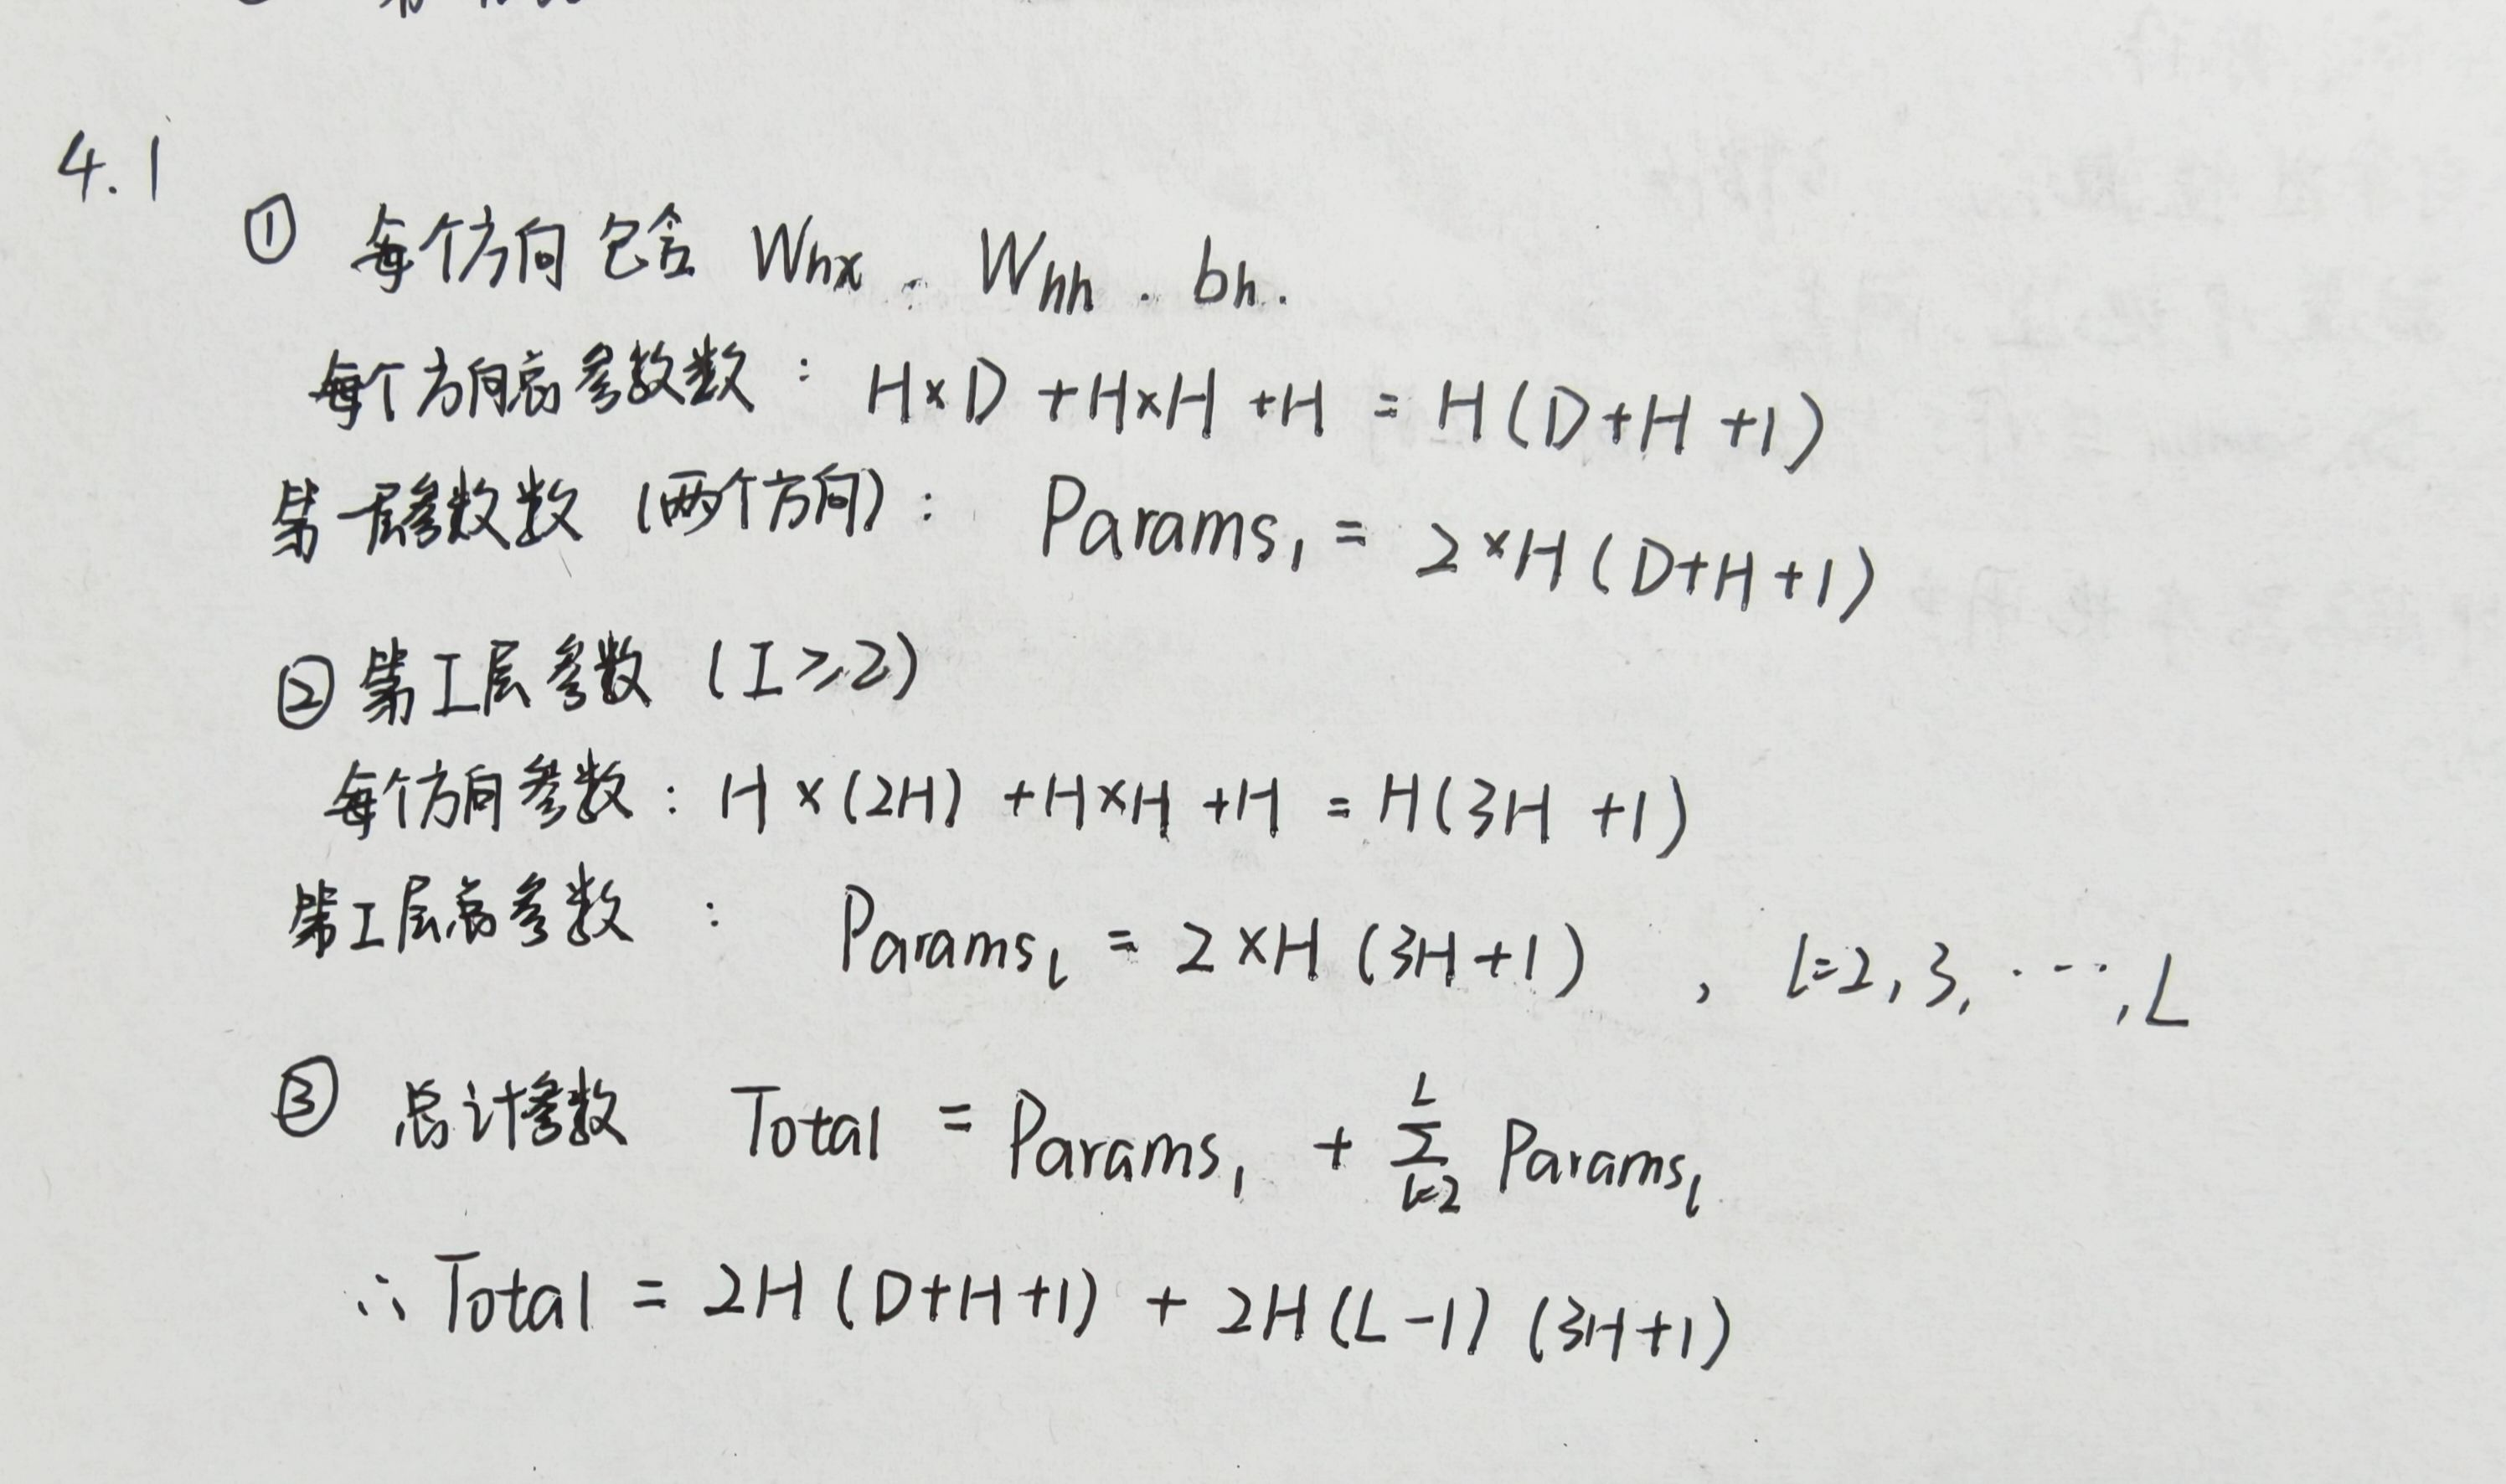

In [4]:
#4.2编程题
import torch
import torch.nn as nn

class BidirectionalRNNEncoder:
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False
        )
    
    def forward(self, X):
        outputs, h_n = self.rnn(X)
        forward_last = h_n[-2, :, :]
        backward_last = h_n[-1, :, :]
        final_state = torch.cat([forward_last, backward_last], dim=-1)
        return outputs, final_state

# ========== 测试输出 ==========
print("="*50)
print("4.2 双向RNN编码器测试")
print("="*50)

seq_len, batch, input_dim, hidden_dim = 5, 3, 4, 6
X = torch.randn(seq_len, batch, input_dim)

print(f"\n输入形状: X = {X.shape} (seq_len={seq_len}, batch={batch}, input_dim={input_dim})")
print(f"参数: hidden_dim={hidden_dim}, num_layers=1")

encoder = BidirectionalRNNEncoder(input_dim, hidden_dim, num_layers=1)
outputs, final_state = encoder.forward(X)

print(f"\n输出结果:")
print(f"  outputs 形状: {outputs.shape} (seq_len, batch, 2*hidden_dim)")
print(f"  final_state 形状: {final_state.shape} (batch, 2*hidden_dim)")

print(f"\n验证维度:")
print(f"  前向隐藏状态维度: {hidden_dim}")
print(f"  后向隐藏状态维度: {hidden_dim}")
print(f"  拼接后维度: {2*hidden_dim}")
print(f"  是否匹配: {outputs.shape[2] == 2*hidden_dim}")

print(f"\n数值示例:")
print(f"  outputs[0,0,:6] (前6维, 即前向部分): {outputs[0,0,:6].detach().numpy()}")
print(f"  outputs[0,0,6:] (后6维, 即后向部分): {outputs[0,0,6:].detach().numpy()}")
print(f"  final_state[0] (拼接后): {final_state[0].detach().numpy()}")

4.2 双向RNN编码器测试

输入形状: X = torch.Size([5, 3, 4]) (seq_len=5, batch=3, input_dim=4)
参数: hidden_dim=6, num_layers=1

输出结果:
  outputs 形状: torch.Size([5, 3, 12]) (seq_len, batch, 2*hidden_dim)
  final_state 形状: torch.Size([3, 12]) (batch, 2*hidden_dim)

验证维度:
  前向隐藏状态维度: 6
  后向隐藏状态维度: 6
  拼接后维度: 12
  是否匹配: True

数值示例:
  outputs[0,0,:6] (前6维, 即前向部分): [ 0.42758435 -0.7358925  -0.02493383 -0.10544696 -0.08387214  0.10896003]
  outputs[0,0,6:] (后6维, 即后向部分): [-0.08075384 -0.17446907  0.3823328   0.6167101   0.39043897  0.09432796]
  final_state[0] (拼接后): [ 0.5752209   0.22032581 -0.3792437   0.00275414  0.22467238 -0.79419404
 -0.08075384 -0.17446907  0.3823328   0.6167101   0.39043897  0.09432796]


5.1 理论计算题

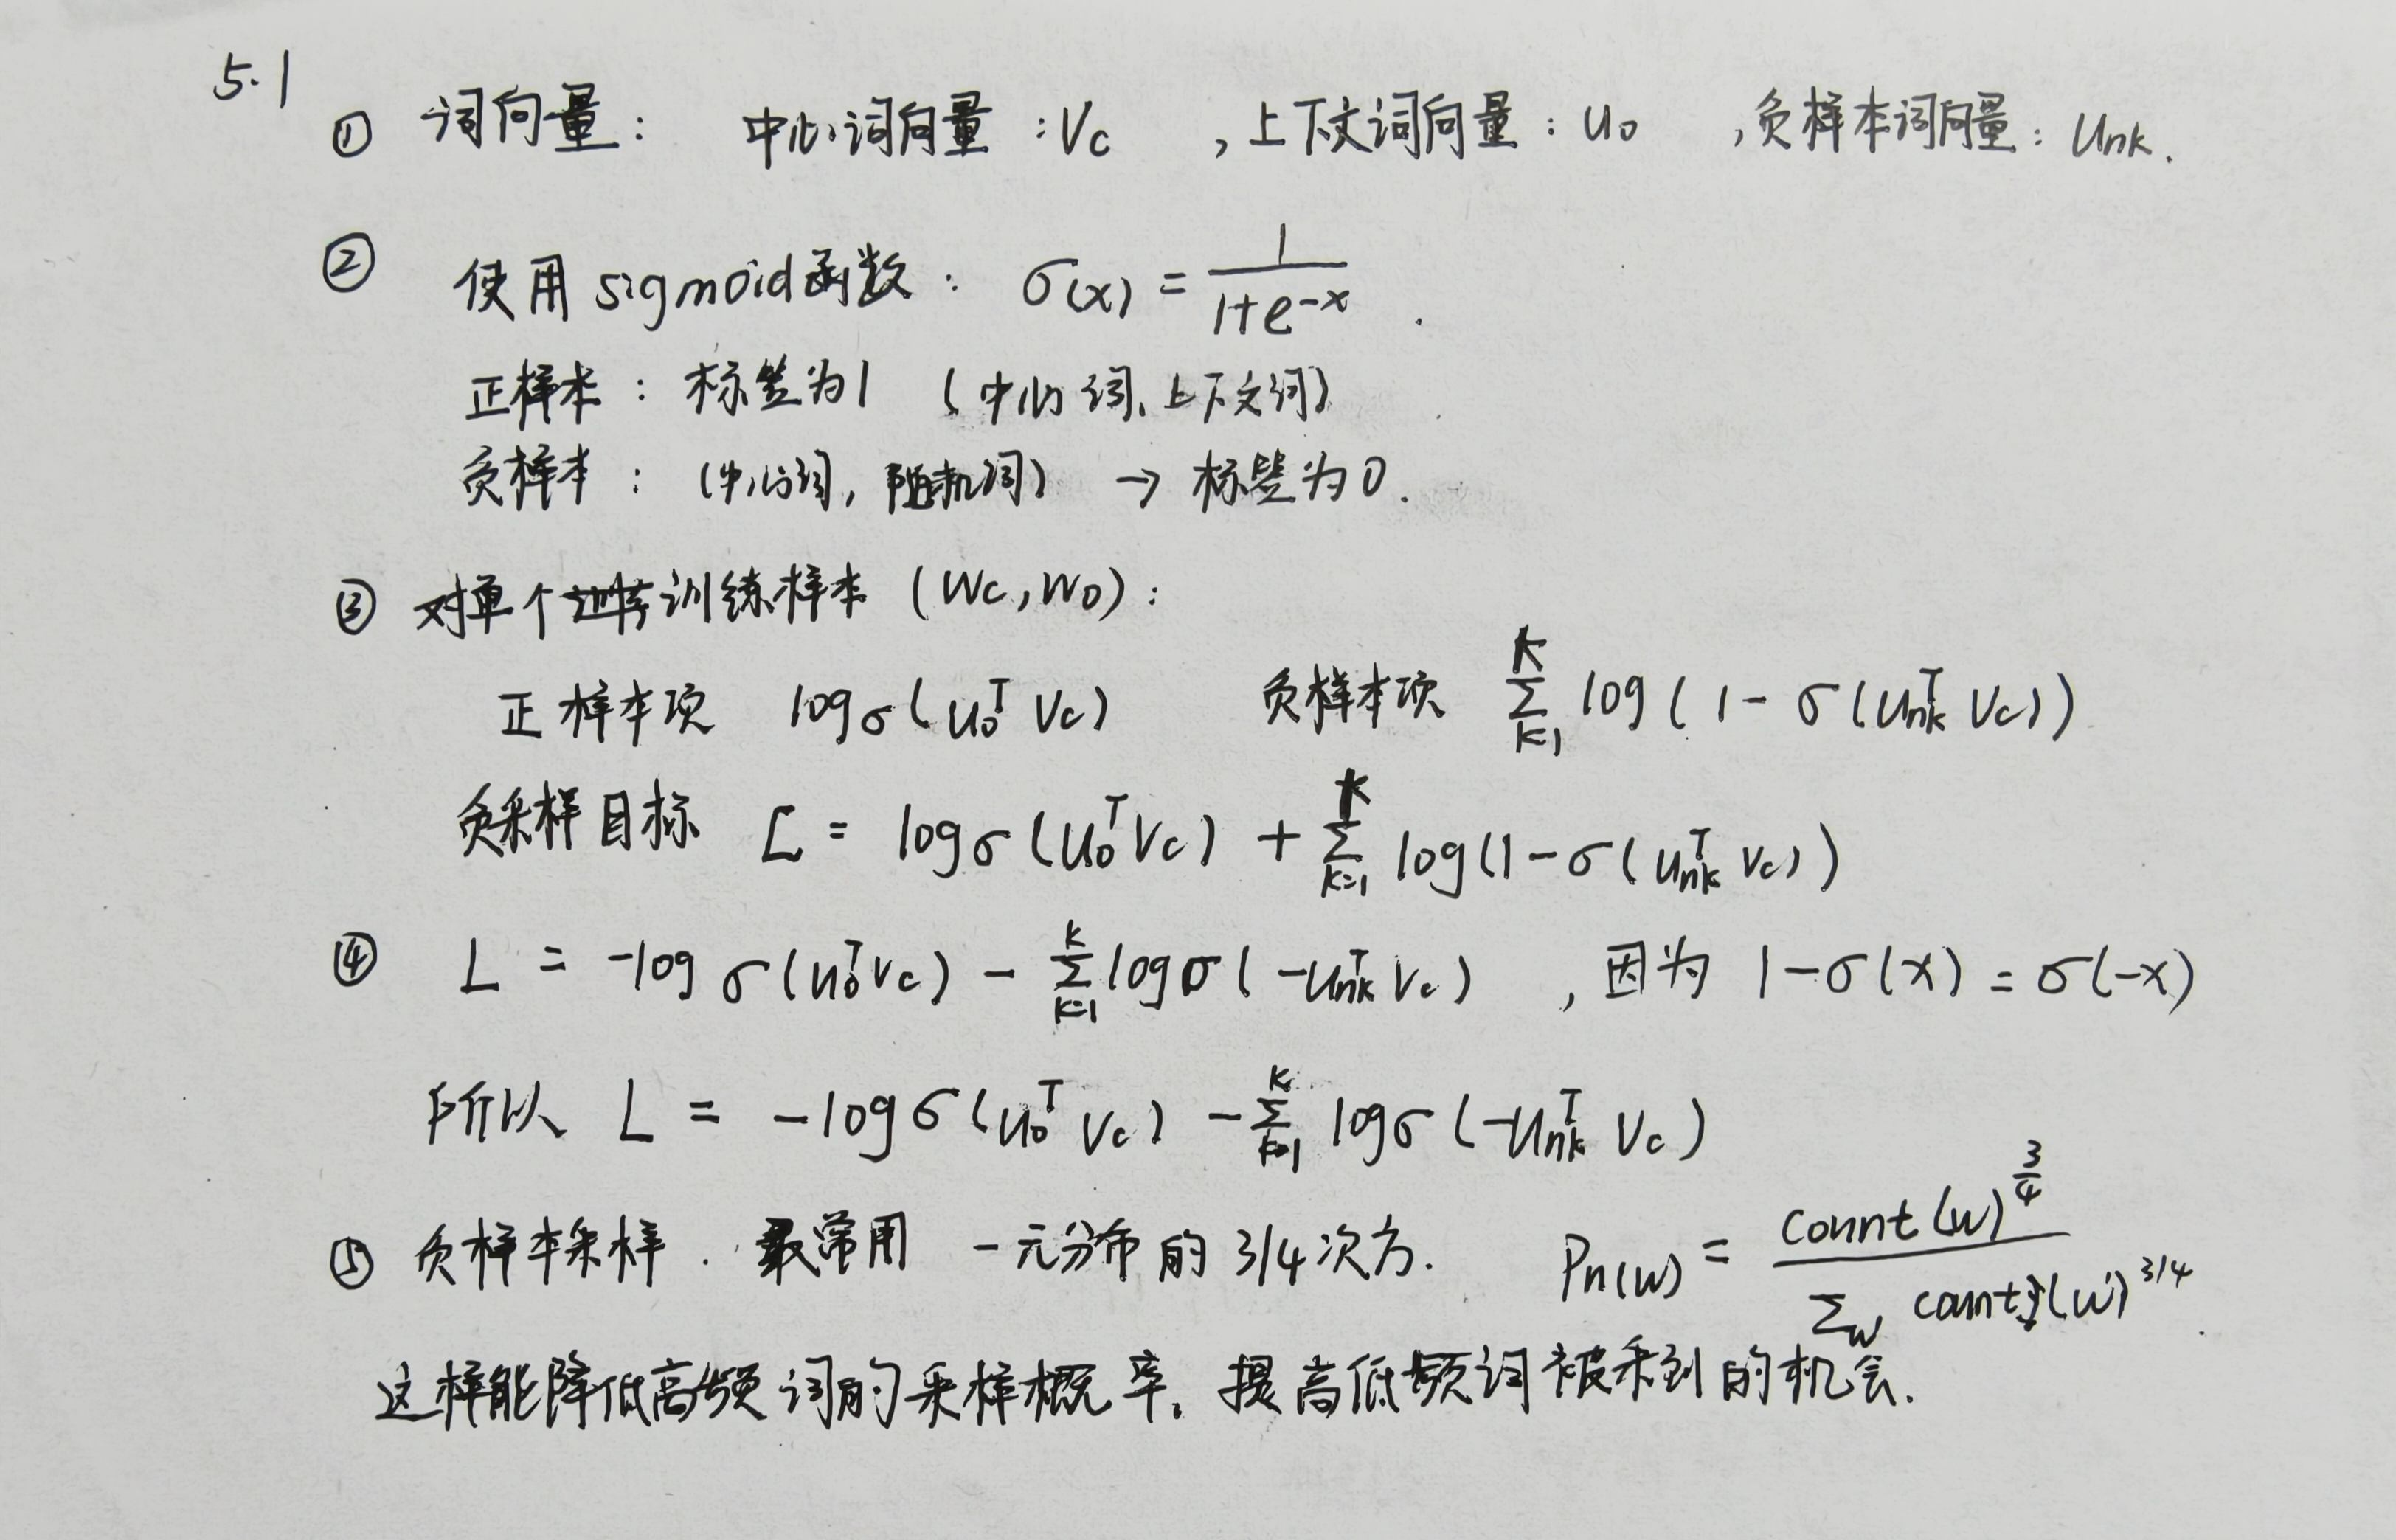

In [5]:
#5.2编程题
import numpy as np

def cbow_forward(context_indices, center_idx, W, W_out):
    context_vectors = W[context_indices]
    h = np.mean(context_vectors, axis=1)
    
    logits = np.dot(h, W_out)
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    batch_size = len(center_idx)
    loss = 0.0
    for i in range(batch_size):
        loss -= np.log(probs[i, center_idx[i]] + 1e-8)
    loss /= batch_size
    
    return loss, probs

# ========== 测试输出 ==========
print("="*50)
print("5.2 CBOW模型 - 前向传播和损失计算测试")
print("="*50)

V, d, context_size, batch = 10, 5, 3, 4
np.random.seed(42)

W = np.random.randn(V, d)
W_out = np.random.randn(d, V)
context_indices = np.random.randint(0, V, size=(batch, context_size))
center_idx = np.random.randint(0, V, size=batch)

print(f"\n模型参数:")
print(f"  词汇表大小 V = {V}")
print(f"  嵌入维度 d = {d}")
print(f"  上下文大小 = {context_size}")
print(f"  Batch大小 = {batch}")
print(f"  W 形状: {W.shape} (V, d)")
print(f"  W_out 形状: {W_out.shape} (d, V)")

print(f"\n输入数据:")
print(f"  context_indices 形状: {context_indices.shape}")
print(f"  context_indices (第一行): {context_indices[0]}")
print(f"  center_idx: {center_idx}")

loss, probs = cbow_forward(context_indices, center_idx, W, W_out)

print(f"\n计算结果:")
print(f"  损失值: {loss:.6f}")
print(f"  概率分布形状: {probs.shape} (batch, V)")
print(f"  第一行概率分布 (前10个): {probs[0, :10]}")
print(f"  第一行概率总和: {np.sum(probs[0]):.6f} (应为1.0)")

# 验证正确性：检查目标词的概率是否合理
target_probs = [probs[i, center_idx[i]] for i in range(batch)]
print(f"\n目标词的概率:")
for i in range(batch):
    print(f"  样本{i}: 目标词索引={center_idx[i]}, 概率={target_probs[i]:.6f}")

5.2 CBOW模型 - 前向传播和损失计算测试

模型参数:
  词汇表大小 V = 10
  嵌入维度 d = 5
  上下文大小 = 3
  Batch大小 = 4
  W 形状: (10, 5) (V, d)
  W_out 形状: (5, 10) (d, V)

输入数据:
  context_indices 形状: (4, 3)
  context_indices (第一行): [8 4 0]
  center_idx: [9 3 6 1]

计算结果:
  损失值: 2.595115
  概率分布形状: (4, 10) (batch, V)
  第一行概率分布 (前10个): [0.06946131 0.02273513 0.04412116 0.1683342  0.1001111  0.38558382
 0.01792161 0.02665483 0.06868279 0.09639405]
  第一行概率总和: 1.000000 (应为1.0)

目标词的概率:
  样本0: 目标词索引=9, 概率=0.096394
  样本1: 目标词索引=3, 概率=0.122941
  样本2: 目标词索引=6, 概率=0.029245
  样本3: 目标词索引=1, 概率=0.089541


6.1 理论计算题

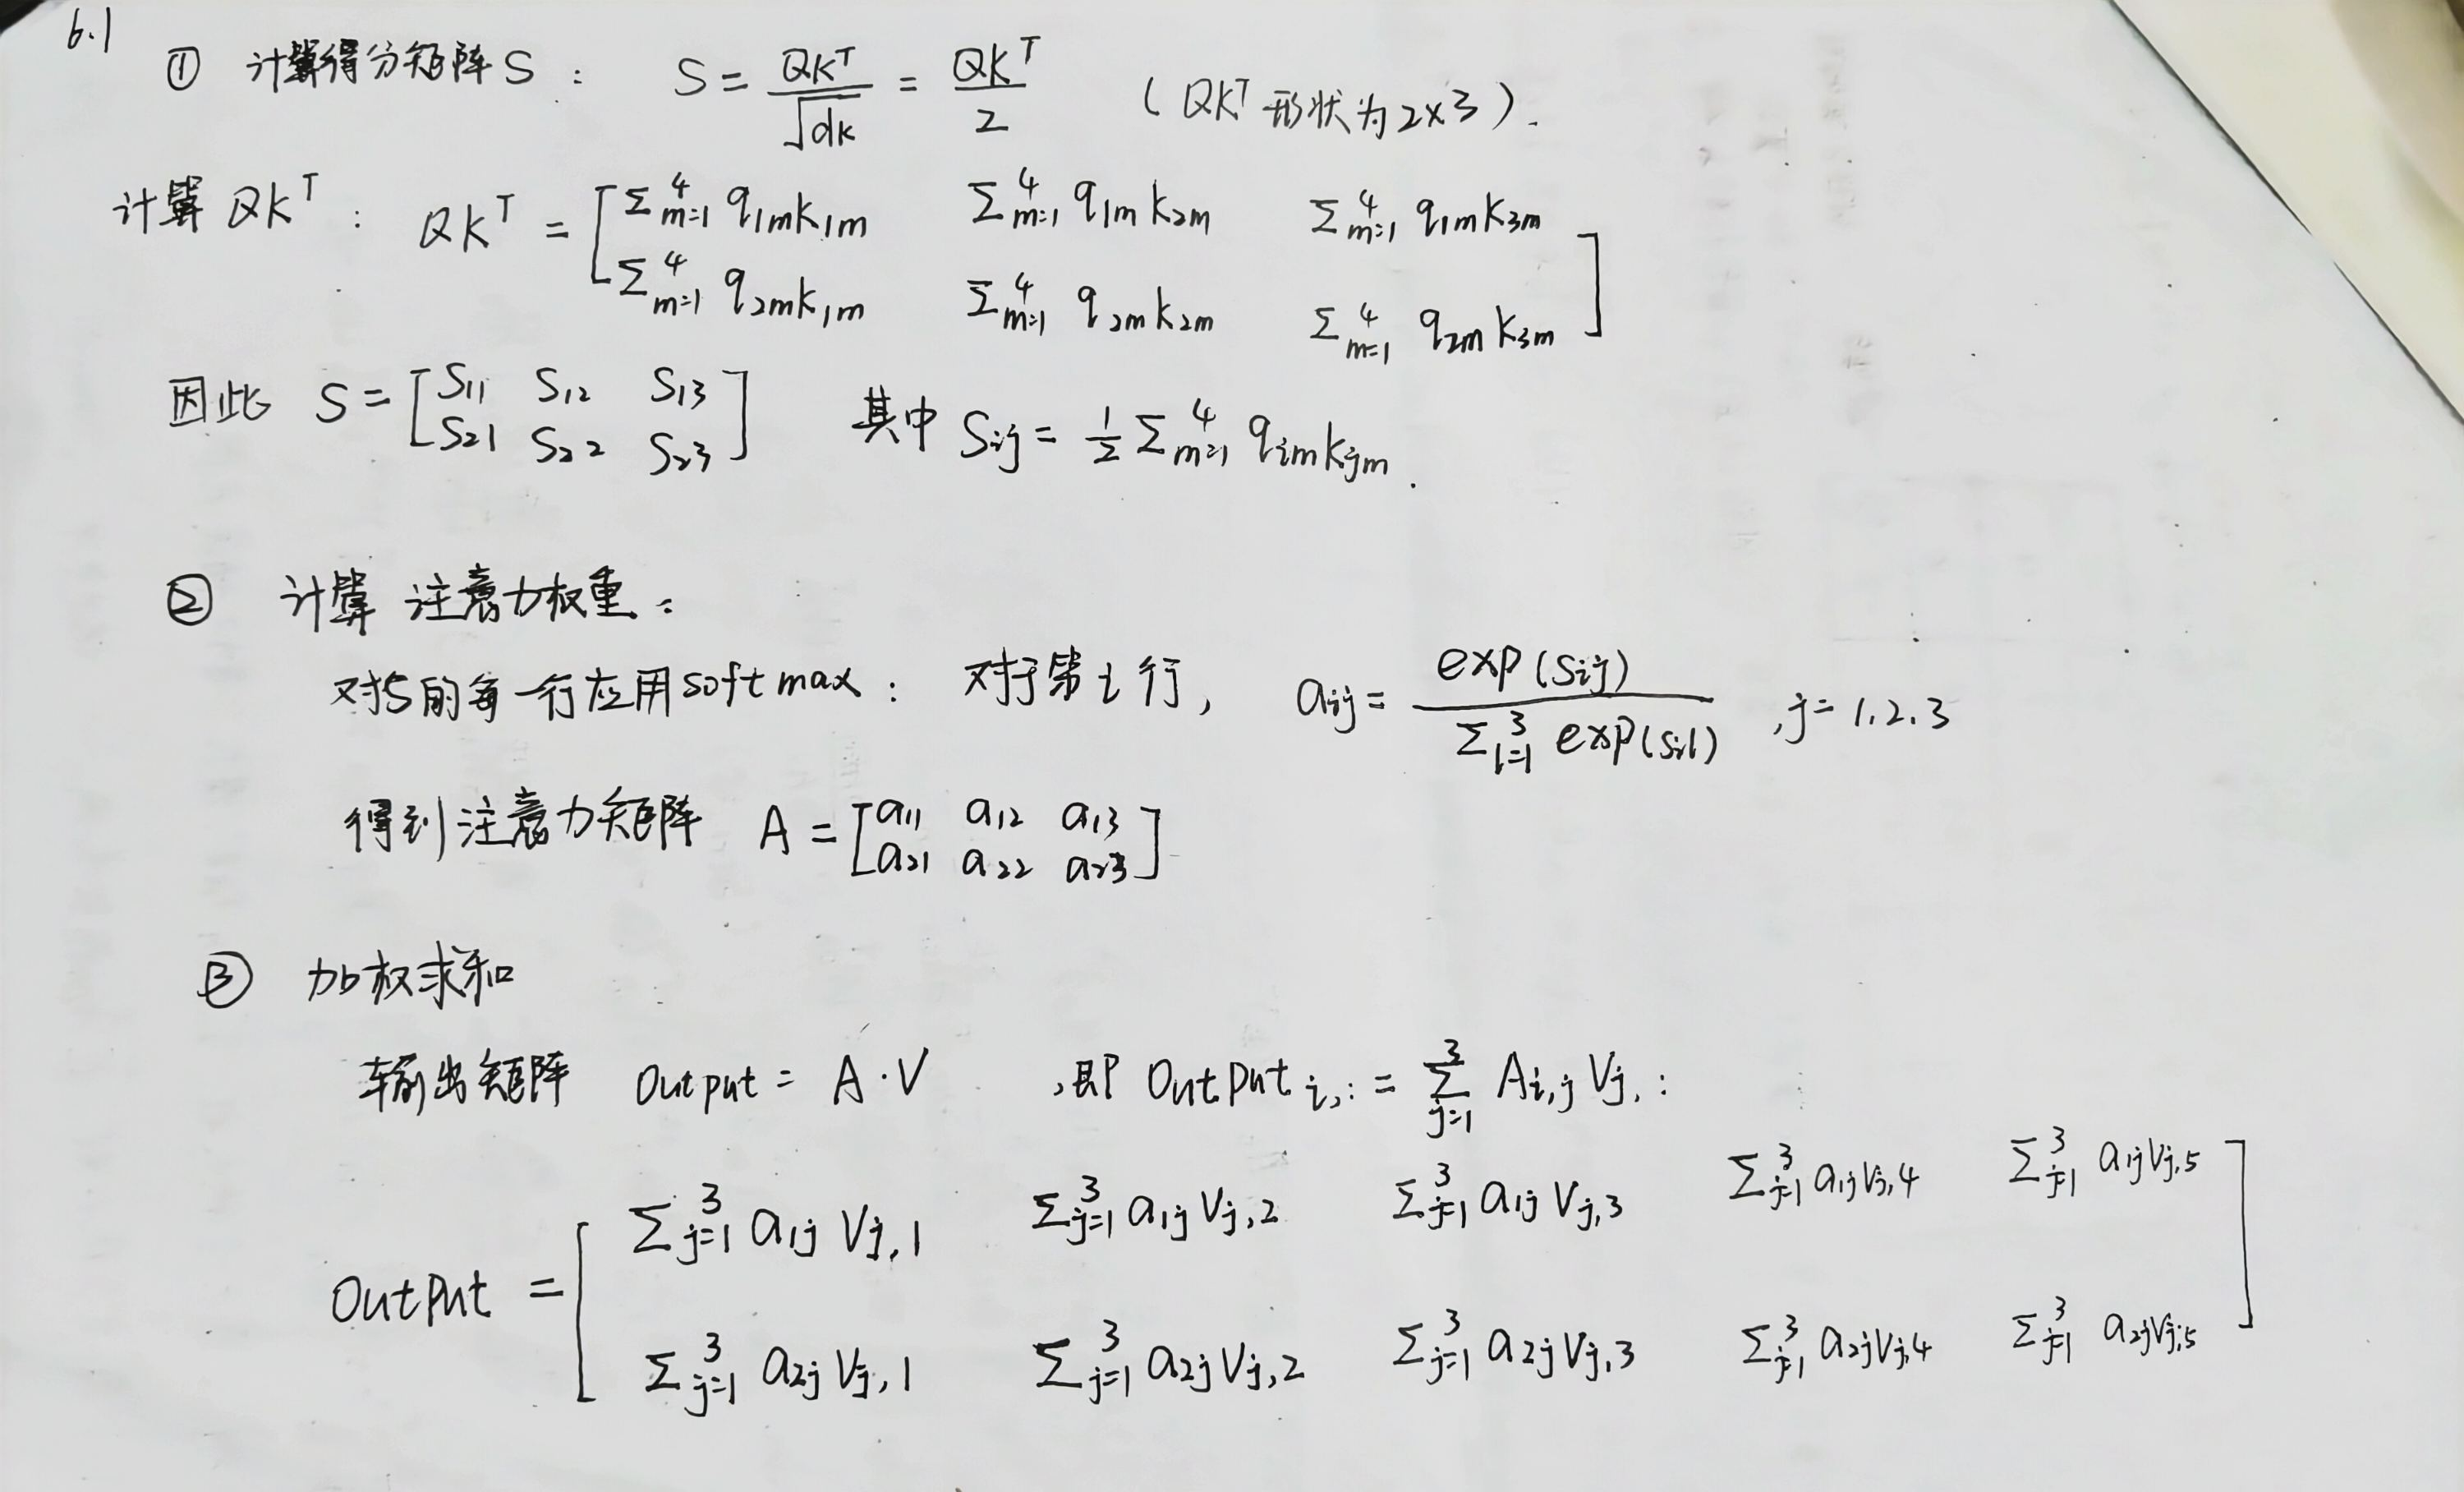

In [6]:
#6.2编程题
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, X):
        seq_len, batch, _ = X.shape
        
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k)
        K = K.view(seq_len, batch, self.num_heads, self.d_k)
        V = V.view(seq_len, batch, self.num_heads, self.d_k)
        
        Q = Q.permute(2, 1, 0, 3)
        K = K.permute(2, 1, 0, 3)
        V = V.permute(2, 1, 0, 3)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)
        
        attn_output = attn_output.permute(2, 1, 0, 3).contiguous()
        attn_output = attn_output.view(seq_len, batch, self.d_model)
        
        output = self.W_o(attn_output)
        return output

# ========== 测试输出 ==========
print("="*50)
print("6.2 多头注意力机制测试")
print("="*50)

d_model, num_heads = 4, 2
seq_len, batch = 6, 3
torch.manual_seed(42)

X = torch.randn(seq_len, batch, d_model)

print(f"\n模型参数:")
print(f"  d_model = {d_model}")
print(f"  num_heads = {num_heads}")
print(f"  d_k = d_v = d_model/num_heads = {d_model//num_heads}")
print(f"  输入形状: X = {X.shape} (seq_len={seq_len}, batch={batch}, d_model={d_model})")

mha = MultiHeadAttention(d_model, num_heads)
out = mha.forward(X)

print(f"\n输出结果:")
print(f"  output 形状: {out.shape} (应与输入形状相同)")
print(f"  形状匹配: {out.shape == X.shape}")

# 查看各注意力头的参数
print(f"\n注意力头信息:")
print(f"  每个头的维度: {d_model//num_heads}")
print(f"  Q, K, V 投影后形状: (seq_len, batch, num_heads, d_k) = ({seq_len}, {batch}, {num_heads}, {d_model//num_heads})")

print(f"\n数值示例:")
print(f"  输入 X[0,0]: {X[0,0].detach().numpy()}")
print(f"  输出 out[0,0]: {out[0,0].detach().numpy()}")
print(f"  变换前后差异: {torch.norm(out[0,0] - X[0,0]).item():.6f}")

6.2 多头注意力机制测试

模型参数:
  d_model = 4
  num_heads = 2
  d_k = d_v = d_model/num_heads = 2
  输入形状: X = torch.Size([6, 3, 4]) (seq_len=6, batch=3, d_model=4)

输出结果:
  output 形状: torch.Size([6, 3, 4]) (应与输入形状相同)
  形状匹配: True

注意力头信息:
  每个头的维度: 2
  Q, K, V 投影后形状: (seq_len, batch, num_heads, d_k) = (6, 3, 2, 2)

数值示例:
  输入 X[0,0]: [ 1.9269153  1.4872841  0.9007172 -2.105521 ]
  输出 out[0,0]: [ 0.13830574  0.14653912 -0.04418282  0.04623598]
  变换前后差异: 3.243396
